In [3]:
ROOT = Path("/kaggle/input/waste-classification-data/DATASET")
TRAIN_DIR = ROOT / "TRAIN"
TEST_DIR  = ROOT / "TEST"

print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists: ", TEST_DIR.exists())

# Count images per class
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
def count_images_in(folder):
    out = {}
    for cls in sorted([p for p in folder.iterdir() if p.is_dir()]):
        files = [f for f in cls.rglob("*") if f.suffix.lower() in IMG_EXTS]
        out[cls.name] = len(files)
    return out

train_counts = count_images_in(TRAIN_DIR)
test_counts  = count_images_in(TEST_DIR)
print("Train counts:", train_counts)
print("Test counts: ", test_counts)
print("Total TRAIN images:", sum(train_counts.values()))
print("Total TEST images: ", sum(test_counts.values()))


TRAIN_DIR exists: True
TEST_DIR exists:  True
Train counts: {'O': 12565, 'R': 9999}
Test counts:  {'O': 1401, 'R': 1112}
Total TRAIN images: 22564
Total TEST images:  2513


In [4]:
# If OOM happens later, lower IMG_SIZE or BATCH_SIZE here and re-run model cell.
IMG_SIZE = (160,160)   # try (128,128) if still OOM
BATCH_SIZE = 8         # try 4 or 2 if still OOM
VAL_SPLIT = 0.15
SEED = 42

print("IMG_SIZE:", IMG_SIZE, "BATCH_SIZE:", BATCH_SIZE)


IMG_SIZE: (160, 160) BATCH_SIZE: 8


In [5]:
from tensorflow.keras.utils import image_dataset_from_directory

# Use TRAIN folder but split into train/val
train_ds = image_dataset_from_directory(
    str(TRAIN_DIR),
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_ds = image_dataset_from_directory(
    str(TRAIN_DIR),
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_ds = image_dataset_from_directory(
    str(TEST_DIR),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Detected classes:", class_names)
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy(),
      "Val batches:", tf.data.experimental.cardinality(val_ds).numpy(),
      "Test batches:", tf.data.experimental.cardinality(test_ds).numpy())


Found 22564 files belonging to 2 classes.
Using 19180 files for training.
Found 22564 files belonging to 2 classes.
Using 3384 files for validation.
Found 2513 files belonging to 2 classes.
Detected classes: ['O', 'R']
Train batches: 2398 Val batches: 423 Test batches: 315


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

# Avoid .cache() to conserve RAM. Keep shuffle+prefetch only.
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# Light augmentation (on-the-fly, reasonably cheap)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.06),
])


In [7]:
# Build model (slim MobileNet)
num_classes = len(class_names)

base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(*IMG_SIZE, 3), alpha=0.35)
base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
# If using mixed precision earlier you'd cast output dtype; we're on CPU so keep default.
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_160            │ (None, 5, 5, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,770 (1.57 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 410,208 (1.56 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

try:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=4,
        callbacks=[es, rlr],
        verbose=1
    )
except tf.errors.ResourceExhaustedError as e:
    print("ResourceExhaustedError (OOM) during fit:", e)
    print("Falling back to creating a small subset. Run the next cell to shrink dataset and retry.")
    history = None


Epoch 1/4
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 325s 130ms/step - accuracy: 0.7636 - loss: 0.5084 - val_accuracy: 0.9078 - val_loss: 0.2388 - learning_rate: 1.0000e-04
Epoch 2/4
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 303s 122ms/step - accuracy: 0.9046 - loss: 0.2487 - val_accuracy: 0.9205 - val_loss: 0.2022 - learning_rate: 1.0000e-04
Epoch 3/4
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 310s 117ms/step - accuracy: 0.9117 - loss: 0.2347 - val_accuracy: 0.9270 - val_loss: 0.1915 - learning_rate: 1.0000e-04
Epoch 4/4
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 297s 119ms/step - accuracy: 0.9149 - loss: 0.2257 - val_accuracy: 0.9294 - val_loss: 0.1816 - learning_rate: 1.0000e-04


315/315 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.9338 - loss: 0.1607
Test accuracy: 88.82%
315/315 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step


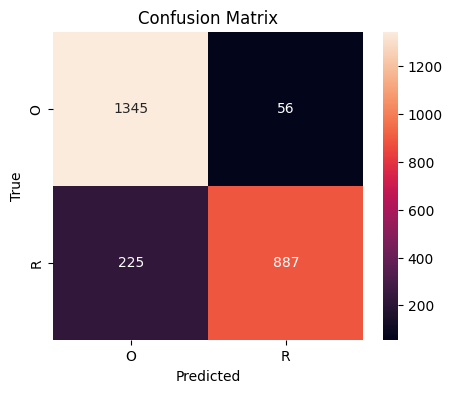

              precision    recall  f1-score   support

           O       0.86      0.96      0.91      1401
           R       0.94      0.80      0.86      1112

    accuracy                           0.89      2513
   macro avg       0.90      0.88      0.88      2513
weighted avg       0.89      0.89      0.89      2513



In [9]:
if 'history' in globals() and history is not None:
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"Test accuracy: {test_acc*100:.2f}%")

    # Create y_true, y_pred
    import numpy as np
    y_true = np.concatenate([y.numpy() for x,y in test_ds], axis=0)
    y_pred = np.argmax(model.predict(test_ds), axis=1)

    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names))
else:
    print("No trained model available (history is None). Train succeeded?")


In [10]:
if 'model' in globals():
    MODEL_OUT = "/kaggle/working/waste_classifier_mobilenetv2_alpha035.h5"
    model.save(MODEL_OUT)
    print("Saved model to:", MODEL_OUT)
else:
    print("No model object found.")


Saved model to: /kaggle/working/waste_classifier_mobilenetv2_alpha035.h5


In [13]:
!ls -lh /kaggle/working/waste_classifier_mobilenetv2_alpha035.h5


-rw-r--r-- 1 root root 2.0M Oct 18 14:49 /kaggle/working/waste_classifier_mobilenetv2_alpha035.h5


In [15]:
import tensorflow as tf
from tensorflow.keras.layers import Lambda
from PIL import Image
import numpy as np
import os

MODEL_PATH = "/kaggle/working/waste_classifier_mobilenetv2_alpha035.h5"

print("Trying load_model with a small custom_objects mapping...")

try:
    # Try mapping TrueDivide to a simple lambda; try common divisors
    clf = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={"TrueDivide": Lambda(lambda x: x / 127.5)}
    )
    print("Loaded with TrueDivide -> divide by 127.5")
except Exception as e1:
    print("127.5 mapping failed:", type(e1).__name__, e1)
    try:
        clf = tf.keras.models.load_model(
            MODEL_PATH,
            custom_objects={"TrueDivide": Lambda(lambda x: x / 255.0)}
        )
        print("Loaded with TrueDivide -> divide by 255.0")
    except Exception as e2:
        print("255.0 mapping failed:", type(e2).__name__, e2)
        try:
            clf = tf.keras.models.load_model(
                MODEL_PATH,
                custom_objects={"TrueDivide": Lambda(lambda x: x)}
            )
            print("Loaded with TrueDivide -> identity (no-op)")
        except Exception as e3:
            print("All attempts failed. Error:", type(e3).__name__, e3)
            clf = None

# quick sanity check if loaded
if clf is not None:
    print("Model summary (top lines):")
    clf.summary(line_length=80)
    # quick prediction check on any available test image (if path exists)
    sample = "/kaggle/input/waste-classification-data/DATASET/TEST/O"
    if os.path.isdir(sample):
        # pick first image found
        found = None
        for f in os.listdir(sample):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                found = os.path.join(sample, f); break
        if found:
            img = Image.open(found).convert('RGB').resize((160,160))
            arr = np.array(img)[None,...]
            probs = clf.predict(arr)
            print("Sample pred probs:", probs[0])
    print("If outputs look numeric, model loaded OK.")
else:
    print("Cell A failed to load model. Run Cell B next.")


Trying load_model with a small custom_objects mapping...
127.5 mapping failed: KeyError 'function'
255.0 mapping failed: KeyError 'function'
All attempts failed. Error: KeyError 'function'
Cell A failed to load model. Run Cell B next.


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from PIL import Image
import numpy as np
import os

IMG_SIZE = (160,160)
MODEL_PATH = "/kaggle/working/waste_classifier_mobilenetv2_alpha035.h5"
class_names = ['O','R']   # your dataset labels; keep exact order

print("Rebuilding architecture and loading weights from .h5 ...")

# Rebuild model EXACTLY as during training (alpha=0.35)
base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(*IMG_SIZE, 3), alpha=0.35)
base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)  # keep preprocessing for inference
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

# Load weights (this reads numeric weights even if model serialization failed)
try:
    model.load_weights(MODEL_PATH)
    clf = model
    print("Weights loaded successfully.")
    clf.summary(line_length=80)
    # quick prediction test on any available test image
    sample_dir = "/kaggle/input/waste-classification-data/DATASET/TEST/O"
    if os.path.isdir(sample_dir):
        found = None
        for f in os.listdir(sample_dir):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                found = os.path.join(sample_dir, f); break
        if found:
            img = Image.open(found).convert('RGB').resize(IMG_SIZE)
            arr = np.array(img)[None,...]
            probs = clf.predict(arr)
            print("Sample pred probs:", probs[0])
    print("If outputs look numeric, model loaded OK.")
except Exception as e:
    print("Failed to load weights from HDF5 file. Error:", type(e).__name__, e)
    print("Please paste the exact error message here.")
    clf = None


Rebuilding architecture and loading weights from .h5 ...
Weights loaded successfully.


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)        │ (None, 160, 160, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)        │ (None, 160, 160, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ subtract_1 (Subtract)             │ (None, 160, 160, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_0.35_160 (Functional) │ (None, 5, 5, 1280)       │       410,208 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d_1        │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 2)                │         2,562 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 412,770 (1.57 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 410,208 (1.56 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Sample pred probs: [0.9947648  0.00523517]
If outputs look numeric, model loaded OK.


In [17]:
# 1) Create synthetic tabular data for CO2 saved per material
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import random
random.seed(42)
np.random.seed(42)

# Map your classes to per-kg CO2 saved (replace with literature/EPA numbers later)
co2_per_kg = {'O': 0.5, 'R': 1.5}   # O = organic, R = recyclable (example numbers)

n = 3000
materials = np.random.choice(list(co2_per_kg.keys()), size=n, p=[0.55,0.45])
weights = np.clip(np.random.gamma(shape=1.0, scale=0.6, size=n), 0.01, 10.0)
co2 = np.array([co2_per_kg[m]*w for m,w in zip(materials, weights)]) * (1 + np.random.normal(0,0.05,size=n))

df = pd.DataFrame({'material':materials, 'weight_kg':weights, 'co2_saved':co2})
print("Synthetic CO2 dataset sample:")
display(df.head())

# One-hot encode material
X = pd.get_dummies(df[['material','weight_kg']], columns=['material'])
y = df['co2_saved']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

rfr = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rfr.fit(X_train, y_train)

pred = rfr.predict(X_test)
print("Regressor MSE:", mean_squared_error(y_test, pred))
print("Regressor R2 :", r2_score(y_test, pred))

# Save regressor and column order (we need cols when predicting)
MODEL_RFR_PATH = "/kaggle/working/co2_regressor_rfr.joblib"
joblib.dump({'model': rfr, 'columns': X_train.columns.tolist()}, MODEL_RFR_PATH)
print("Saved regressor to:", MODEL_RFR_PATH)


Synthetic CO2 dataset sample:


,material,weight_kg,co2_saved
0,O,0.670132,0.317540
1,R,0.955789,1.467619
2,R,0.172984,0.263250
3,R,0.588296,0.924706
4,O,0.508823,0.244351


Regressor MSE: 0.0026181787034279423
Regressor R2 : 0.993814366047854
Saved regressor to: /kaggle/working/co2_regressor_rfr.joblib


In [18]:
# 2) Load classifier (clf) and RFR, and create inference helper
import tensorflow as tf
import joblib
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path

# load clf if not already in memory (adjust path if needed)
MODEL_PATH = "/kaggle/working/waste_classifier_mobilenetv2_alpha035.h5"
try:
    if 'clf' not in globals():
        clf = tf.keras.models.load_model(MODEL_PATH)
        print("Loaded classifier from", MODEL_PATH)
    else:
        print("Classifier already in memory.")
except Exception as e:
    print("If this errors, you already have clf from previous cells (OK).", e)

rfr_bundle = joblib.load("/kaggle/working/co2_regressor_rfr.joblib")
rfr = rfr_bundle['model']
rfr_cols = rfr_bundle['columns']
print("Loaded RFR and cols:", rfr_cols)

# class_names — ensure matches your training order
class_names = ['O','R']

def predict_image_co2_from_pil(img_pil, weight_kg, clf=clf, rfr=rfr, rfr_cols=rfr_cols, img_size=(160,160)):
    # img_pil: PIL Image object (RGB)
    img = img_pil.convert('RGB').resize(img_size)
    arr = np.array(img)[None,...]   # shape (1,H,W,3)
    probs = clf.predict(arr)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    # build reg input with same columns as training
    d = {c:0 for c in rfr_cols}
    d['weight_kg'] = float(weight_kg)
    colname = f"material_{pred_class}"
    if colname in d:
        d[colname] = 1
    reg_df = pd.DataFrame([d])
    co2_pred = float(rfr.predict(reg_df)[0])
    return {'pred_class': pred_class, 'prob': float(probs[pred_idx]), 'co2_saved_kg': co2_pred}

# Quick test using a sample test image (if path exists)
test_sample_dir = Path("/kaggle/input/waste-classification-data/DATASET/TEST/O")
if test_sample_dir.exists():
    for f in test_sample_dir.iterdir():
        if f.suffix.lower() in ('.jpg','.jpeg','.png'):
            sample_img = Image.open(f)
            break
    out = predict_image_co2_from_pil(sample_img, weight_kg=0.3)
    print("Example prediction:", out)
else:
    print("Sample test directory not found; skip quick test.")


Classifier already in memory.
Loaded RFR and cols: ['weight_kg', 'material_O', 'material_R']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Example prediction: {'pred_class': 'O', 'prob': 0.9947648048400879, 'co2_saved_kg': 0.15043210328655984}


In [19]:
# 3) Create demo user profiles (synthetic), cluster them, and create simple textual tips
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# aggregate synthetic user histories from df created earlier
n_users = 200
user_rows = []
for uid in range(n_users):
    sub = df.sample(np.random.randint(8,60))
    total_w = sub['weight_kg'].sum()
    avg_co2 = sub['co2_saved'].mean()
    frac_O = (sub['material']=='O').mean()
    frac_R = (sub['material']=='R').mean()
    user_rows.append({'user_id':uid,'total_weight':total_w,'avg_co2':avg_co2,'frac_O':frac_O,'frac_R':frac_R})
users_df = pd.DataFrame(user_rows).set_index('user_id')

features = users_df[['total_weight','avg_co2','frac_O','frac_R']]
scaler = StandardScaler()
Xc = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42).fit(Xc)
users_df['cluster'] = kmeans.labels_

# Describe clusters for tips
cluster_summary = users_df.groupby('cluster').mean()
print("Cluster summary (means):")
display(cluster_summary)

# Create simple tips per cluster
tips = {}
for c in cluster_summary.index:
    row = cluster_summary.loc[c]
    if row['frac_R'] > 0.6:
        tips[c] = "You're recycle-heavy — great! Try to reduce single-use plastics and ensure items are clean."
    elif row['frac_O'] > 0.6:
        tips[c] = "You're organic-heavy — consider home composting or local community compost programs."
    else:
        tips[c] = "Mixed recycler — separate organics from recyclables and clean recyclables to avoid contamination."

print("Cluster tips:", tips)


Cluster summary (means):


,total_weight,avg_co2,frac_O,frac_R
cluster,,,,
0,15.045234,0.634487,0.450897,0.549103
1,12.880263,0.435051,0.640019,0.359981
2,28.496012,0.570731,0.549355,0.450645


Cluster tips: {0: 'Mixed recycler — separate organics from recyclables and clean recyclables to avoid contamination.', 1: "You're organic-heavy — consider home composting or local community compost programs.", 2: 'Mixed recycler — separate organics from recyclables and clean recyclables to avoid contamination.'}


In [20]:
# 4) Write a minimal Streamlit app that uses clf and rfr
app_code = r'''
import streamlit as st
from PIL import Image
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

@st.cache(allow_output_mutation=True)
def load_models():
    clf = tf.keras.models.load_model("/kaggle/working/waste_classifier_mobilenetv2_alpha035.h5")
    rfr_bundle = joblib.load("/kaggle/working/co2_regressor_rfr.joblib")
    rfr = rfr_bundle['model']; cols = rfr_bundle['columns']
    return clf, rfr, cols

clf, rfr, cols = load_models()
CLASS_NAMES = ['O','R']

st.title("EcoWaste AI — Minimal Demo")
uploaded = st.file_uploader("Upload waste image", type=['jpg','jpeg','png'])
weight = st.number_input("Estimated weight (kg)", min_value=0.01, value=0.2, step=0.01)

def predict(arr, weight):
    probs = clf.predict(arr)[0]
    idx = int(np.argmax(probs))
    cls = CLASS_NAMES[idx]
    d = {c:0 for c in cols}
    d['weight_kg'] = float(weight)
    d[f'material_{cls}'] = 1
    reg_df = pd.DataFrame([d])
    co2 = rfr.predict(reg_df)[0]
    return cls, float(probs[idx]), float(co2)

if uploaded:
    img = Image.open(uploaded).convert('RGB').resize((160,160))
    st.image(img, caption="Input image", use_column_width=True)
    arr = np.array(img)[None,...]
    pred_cls, prob, co2 = predict(arr, weight)
    st.markdown(f"**Predicted class:** {pred_cls} (confidence {prob:.2f})")
    st.metric("Estimated CO₂ saved (kg)", f"{co2:.2f}")
    if pred_cls == 'R':
        st.info("Tip: This item is recyclable — clean & dry before recycling.")
    else:
        st.info("Tip: This item is organic — consider composting.")
'''
with open("/kaggle/working/app.py","w") as f:
    f.write(app_code)
print("Wrote Streamlit app to /kaggle/working/app.py")
print("Run locally with: streamlit run app.py (or use ngrok/tunnel for Colab).")


Wrote Streamlit app to /kaggle/working/app.py
Run locally with: streamlit run app.py (or use ngrok/tunnel for Colab).


In [21]:
# Save classifier in both formats
import tensorflow as tf
import os

# adjust to your model object or path
if 'clf' not in globals():
    MODEL_PATH_H5 = "/kaggle/working/waste_classifier_mobilenetv2_alpha035.h5"
    clf = tf.keras.models.load_model(MODEL_PATH_H5)  # if you have .h5 saved earlier
else:
    clf = clf

OUT_DIR = "/content/models_export"
os.makedirs(OUT_DIR, exist_ok=True)

# Save new Keras native format (.keras)
keras_path = os.path.join(OUT_DIR, "waste_classifier_mobilenetv2_alpha035.keras")
clf.save(keras_path)
print("Saved .keras model:", keras_path)

# Save legacy HDF5 as well for compatibility
h5_path = os.path.join(OUT_DIR, "waste_classifier_mobilenetv2_alpha035.h5")
clf.save(h5_path)
print("Saved .h5 model:", h5_path)


Saved .keras model: /content/models_export/waste_classifier_mobilenetv2_alpha035.keras
Saved .h5 model: /content/models_export/waste_classifier_mobilenetv2_alpha035.h5


In [22]:
# Save regressor (joblib) and columns (json)
import joblib, json, os

# rfr: RandomForestRegressor object in memory from earlier
# rfr_cols: list of column names used to train the regressor (from earlier code)
# If not in memory, load your saved joblib instead (adjust path)
if 'rfr' not in globals() or 'rfr_cols' not in globals():
    # try load existing saved joblib
    possible = "/kaggle/working/co2_regressor_rfr.joblib"
    if os.path.exists(possible):
        bundle = joblib.load(possible)
        rfr = bundle['model']
        rfr_cols = bundle['columns']
    else:
        raise RuntimeError("rfr or rfr_cols not in memory and no joblib found at default path.")

out_rfr = os.path.join("/content/models_export", "co2_regressor_rfr.joblib")
joblib.dump({'model': rfr, 'columns': rfr_cols}, out_rfr)
print("Saved regressor bundle:", out_rfr)

# also save columns to JSON for easier reading
cols_json = os.path.join("/content/models_export", "rfr_columns.json")
with open(cols_json, "w") as f:
    json.dump(rfr_cols, f)
print("Saved columns JSON:", cols_json)


Saved regressor bundle: /content/models_export/co2_regressor_rfr.joblib
Saved columns JSON: /content/models_export/rfr_columns.json


In [23]:
# Save KMeans and StandardScaler if you created them in-session (users_df, kmeans, scaler)
import joblib, os

# If they exist in memory, save; otherwise skip with a message
if 'kmeans' in globals():
    joblib.dump(kmeans, "/content/models_export/kmeans_users.joblib")
    print("Saved kmeans_users.joblib")
else:
    print("kmeans object not found in memory; skipping saving kmeans.")

if 'scaler' in globals():
    joblib.dump(scaler, "/content/models_export/users_scaler.joblib")
    print("Saved users_scaler.joblib")
else:
    print("scaler object not found in memory; skipping saving scaler.")


Saved kmeans_users.joblib
Saved users_scaler.joblib
